# EDA: отмены бронирования отеля

Датасет Hotel Booking Demand (Antonio et al., 2019). Задача - бинарная классификация, цель `is_canceled`.

Посмотрим что внутри: сколько строк, какие типы, где пропуски, как распределена цель.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 40)

In [2]:
df = pd.read_csv('../data/hotels.csv')
df.shape

(119390, 32)

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
df.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

In [5]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


### Пропуски

In [6]:
na = df.isna().sum()
na[na > 0].sort_values(ascending=False)

company     112593
agent        16340
country        488
children         4
dtype: int64

`company` почти пустой (около 94% NaN), `agent` тоже много, `country` немного, `children` - чуть-чуть. `company` в таком виде бесполезен, превратим в бинарный флаг на этапе препроцессинга.

### Таргет

In [7]:
df['is_canceled'].value_counts(normalize=True).rename({0:'stay', 1:'cancel'})

is_canceled
stay      0.629584
cancel    0.370416
Name: proportion, dtype: float64

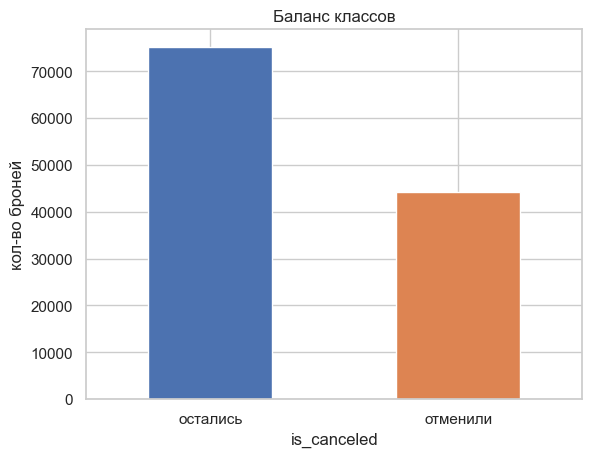

In [8]:
ax = df['is_canceled'].value_counts().plot(kind='bar', color=['#4c72b0', '#dd8452'])
ax.set_xticklabels(['остались', 'отменили'], rotation=0)
ax.set_ylabel('кол-во броней')
ax.set_title('Баланс классов')
plt.show()

Отмен около 37%. Дисбаланс умеренный, бороться с ним спец. средствами не надо.

### Разрез по отелю

In [9]:
by_hotel = df.groupby('hotel')['is_canceled'].agg(['mean', 'count'])
by_hotel

,mean,count
hotel,,
City Hotel,0.417270,79330
Resort Hotel,0.277634,40060


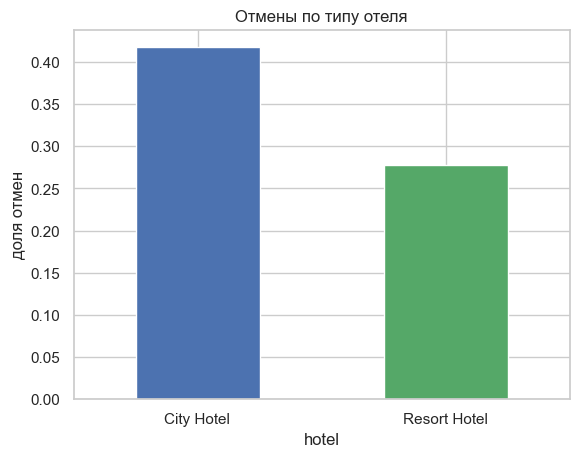

In [10]:
ax = by_hotel['mean'].plot(kind='bar', color=['#4c72b0', '#55a868'])
ax.set_ylabel('доля отмен')
ax.set_title('Отмены по типу отеля')
plt.xticks(rotation=0)
plt.show()

City Hotel отменяют заметно чаще, чем Resort (около 42% против 28%). Разная клиентура, разный lead_time и цена - дальше видно.

### lead_time

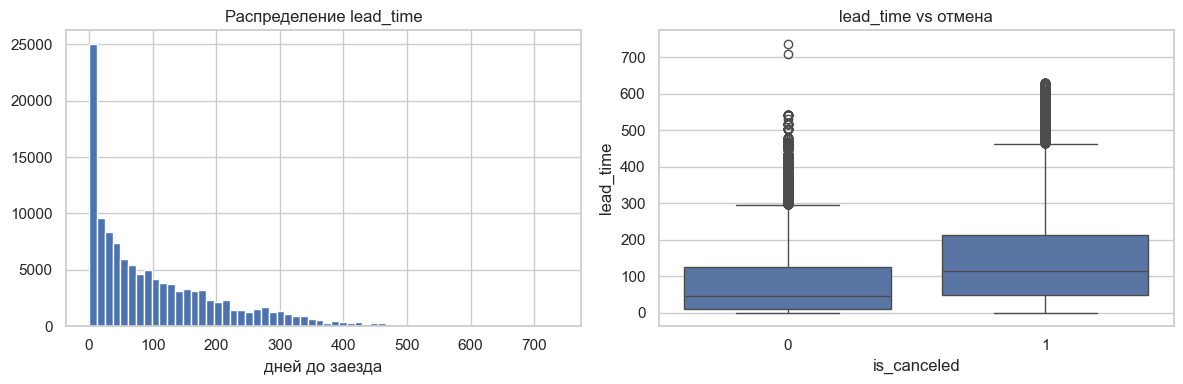

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df['lead_time'].hist(bins=60, ax=ax[0], color='#4c72b0')
ax[0].set_title('Распределение lead_time')
ax[0].set_xlabel('дней до заезда')
sns.boxplot(data=df, x='is_canceled', y='lead_time', ax=ax[1])
ax[1].set_title('lead_time vs отмена')
plt.tight_layout()
plt.show()

In [12]:
df.groupby('is_canceled')['lead_time'].agg(['mean', 'median'])

,mean,median
is_canceled,,
0,79.984687,45.0
1,144.848815,113.0


Отменяющие бронируют сильно заранее: средний lead_time почти в 2 раза больше. Это главный сигнал в датасете.

### deposit_type

In [13]:
df.groupby('deposit_type')['is_canceled'].agg(['mean', 'count']).sort_values('count', ascending=False)

,mean,count
deposit_type,,
No Deposit,0.283770,104641
Non Refund,0.993624,14587
Refundable,0.222222,162


Парадокс: в группе `Non Refund` почти 100% отмен. Это известная особенность датасета - скорее всего так помечены брони которые формально не возвращаются, но фактически всё равно пропадают. В любом случае, это сильный сигнал.

### market_segment и customer_type

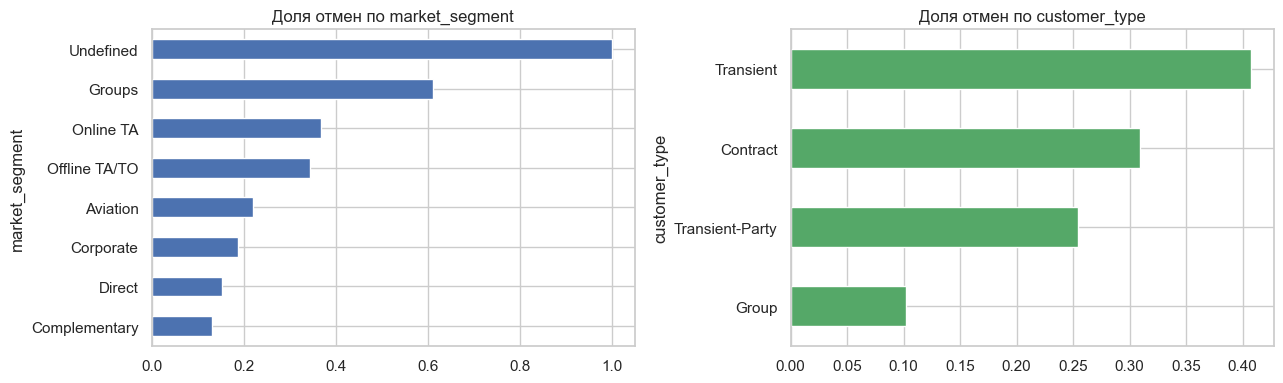

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
(df.groupby('market_segment')['is_canceled'].mean()
   .sort_values().plot(kind='barh', ax=ax[0], color='#4c72b0'))
ax[0].set_title('Доля отмен по market_segment')
(df.groupby('customer_type')['is_canceled'].mean()
   .sort_values().plot(kind='barh', ax=ax[1], color='#55a868'))
ax[1].set_title('Доля отмен по customer_type')
plt.tight_layout()
plt.show()

Группы (`Groups`) и онлайн-TA отменяют чаще всего, `Complementary` и `Aviation` почти не отменяют.

### Сезонность

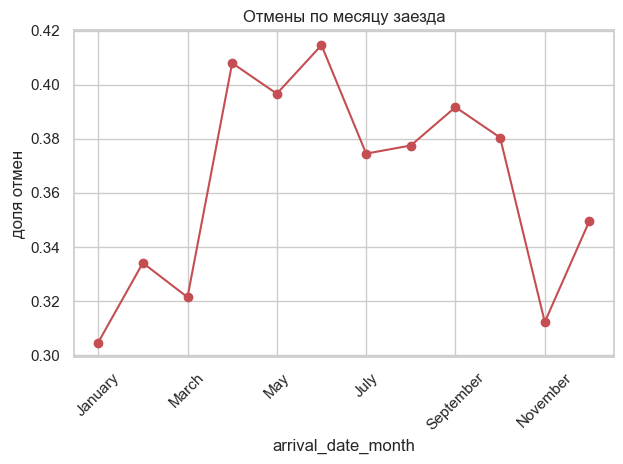

In [15]:
months_order = ['January','February','March','April','May','June',
                'July','August','September','October','November','December']
by_month = df.groupby('arrival_date_month')['is_canceled'].mean().reindex(months_order)
ax = by_month.plot(kind='line', marker='o', color='#c44e52')
ax.set_ylabel('доля отмен')
ax.set_title('Отмены по месяцу заезда')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

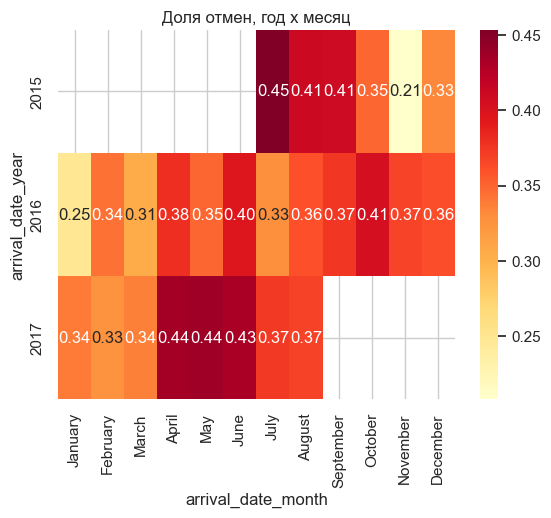

In [16]:
heat = (df.pivot_table(index='arrival_date_year', columns='arrival_date_month',
                        values='is_canceled', aggfunc='mean')
         .reindex(columns=months_order))
sns.heatmap(heat, cmap='YlOrRd', annot=True, fmt='.2f')
plt.title('Доля отмен, год x месяц')
plt.show()

Лето проседает (больше отмен), зимой поменьше. Год на год мало влияет.

### country

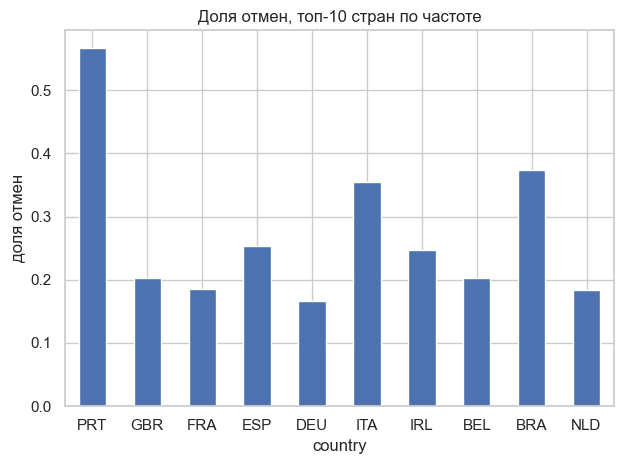

In [17]:
top = df['country'].value_counts().head(10).index
sub = df[df['country'].isin(top)]
by_c = sub.groupby('country')['is_canceled'].mean().loc[top]
ax = by_c.plot(kind='bar', color='#4c72b0')
ax.set_title('Доля отмен, топ-10 стран по частоте')
ax.set_ylabel('доля отмен')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

PRT (Португалия) - самая частая страна и отменяет заметно больше остальных. Логично: отели португальские, местные могут бронировать "на всякий случай".

### adr

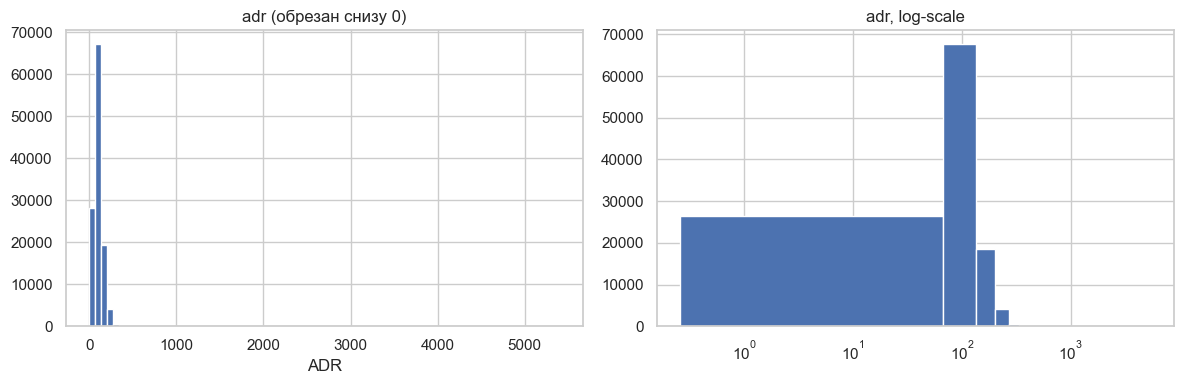

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df['adr'].clip(lower=0).hist(bins=80, ax=ax[0], color='#4c72b0')
ax[0].set_title('adr (обрезан снизу 0)')
ax[0].set_xlabel('ADR')
df.loc[df['adr'] > 0, 'adr'].hist(bins=80, ax=ax[1], color='#4c72b0')
ax[1].set_xscale('log')
ax[1].set_title('adr, log-scale')
plt.tight_layout()
plt.show()

In [19]:
print('min:', df['adr'].min(), '| max:', df['adr'].max())
print('adr < 0:', (df['adr'] < 0).sum())
print('adr > 1000:', (df['adr'] > 1000).sum())

min: -6.38 | max: 5400.0
adr < 0: 1
adr > 1000: 1


В adr есть странности: одна строка с отрицательной ценой и одна с 5400. Уберём на этапе чистки.

### Несоответствие номера

In [20]:
mism = (df['reserved_room_type'] != df['assigned_room_type']).mean()
print(f'доля бронирований где выдали другой номер: {mism:.1%}')
print()
print('отмены в группе "дали другой номер":')
print(df.groupby(df['reserved_room_type'] != df['assigned_room_type'])['is_canceled'].mean())

доля бронирований где выдали другой номер: 12.5%

отмены в группе "дали другой номер":
False    0.415629
True     0.053764
Name: is_canceled, dtype: float64


Когда номер меняют - отмен сильно меньше. Интуитивно понятно: клиент уже заехал или идёт на заселение, это поздно отменять.

### Корреляции числовых фич

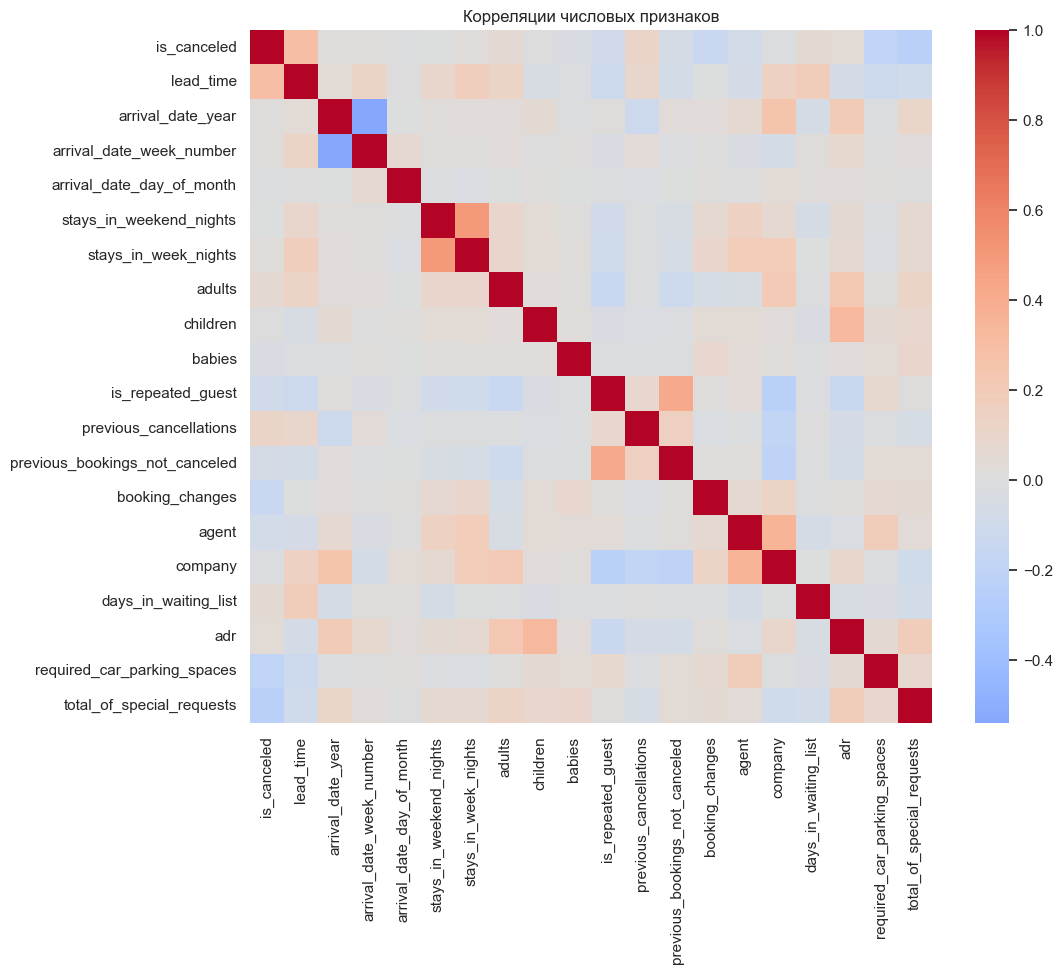

In [21]:
num_cols = df.select_dtypes('number').columns.tolist()
corr = df[num_cols].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Корреляции числовых признаков')
plt.show()

In [22]:
corr['is_canceled'].drop('is_canceled').sort_values(key=abs, ascending=False).head(10)

lead_time                         0.293123
total_of_special_requests        -0.234658
required_car_parking_spaces      -0.195498
booking_changes                  -0.144381
previous_cancellations            0.110133
is_repeated_guest                -0.084793
agent                            -0.083114
adults                            0.060017
previous_bookings_not_canceled   -0.057358
days_in_waiting_list              0.054186
Name: is_canceled, dtype: float64

Сильных линейных корреляций с таргетом почти нет кроме `lead_time` и `previous_cancellations`. Это нормально - ожидаем что бустинг хорошо возьмёт нелинейные взаимодействия.

### Утечки

`reservation_status` и `reservation_status_date` - это прямое описание того что случилось с бронью. Использовать их как фичи нельзя, будут выкинуты перед обучением. Ниже - подтверждение что status полностью определяет таргет.

In [23]:
pd.crosstab(df['reservation_status'], df['is_canceled'])

is_canceled,0,1
reservation_status,,
Canceled,0,43017
Check-Out,75166,0
No-Show,0,1207


### Итог EDA

- таргет 37/63, imbalanced-трюки не нужны
- главные сигналы: lead_time, deposit_type, previous_cancellations, market_segment
- country - 175+ значений, OHE взорвёт размерность, будем делать target encoding
- `company` почти пустой, сделаем бинарный флаг
- adr нужно почистить от выбросов
- `reservation_status*` выкидываем как утечку